# PROC GREDUCE로 빠른 물류 대시보드용 배송권역 지도 상세도 줄이기

## 요약

한 지역 소포 운송업체는 서비스 권역 경계를 조밀한 폴리곤 윤곽으로 저장하고 있어, 경로 계획 대시보드가 이를 다시 그릴 때 속도가 느립니다. 이 노트북은 네 개 배송권역의 경계 좌표를 합성하고, **PROC GREDUCE**로 모든 경계 정점에 `DENSITY` 등급을 부여한 다음, 축소된 상세도 등급으로 **PROC GMAP**을 사용해 정시배송 단계구분도를 그려 지도가 더 빠르게 그려지면서도 각 구역을 여전히 알아볼 수 있게 합니다.

GREDUCE는 96개 경계점을 세 등급으로 분류했습니다: `DENSITY=0`인 점 10개, `DENSITY=2`인 점 44개, `DENSITY=3`인 점 42개. 저해상도 등급(`DENSITY <= 2`)만 남기면 지도는 정점 96개에서 54개로 줄어듭니다 — 약 44% 감소 — 그럼에도 아래의 나란한 비교에서 네 구역은 뚜렷하게 구분됩니다.

## 데이터 출처

모든 데이터는 아래 DATA 스텝에서 인라인으로 생성됩니다 — 외부 파일이나 네트워크 접근 없음.

| 데이터셋 | 행 수 | 주요 변수 | 설명 |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4개 구역 x 24개 정점) | `zone` (ID), `x`, `y` | 네 개 배송 서비스 구역의 합성 닫힌 폴리곤 경계 좌표. 각 구역은 24개 정점으로 그려진 흔들린(jittered) 타원이라 밀도 축소를 적용할 대상이 있습니다. |
| `reducedmap` | 96 | `density` 추가 | PROC GREDUCE의 출력: 선택적 렌더링을 위해 `DENSITY` 등급(여기서는 0, 2, 3)이 부여된 경계점. |
| `coarsemap` | 54 | `reducedmap`의 부분집합 | `DENSITY <= 2` 부분집합 — 축소 상세도 대시보드 지도에 사용되는 저해상도 고속 렌더링 등급. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | 구역별 응답 행 1개: 합성 정시배송율과 일일 소포 물량으로, 단계구분도를 위해 지도와 조인됩니다. |

> **표본 크기에 대한 참고.** 이 환경은 라이선스 없이 실행되므로 각 DATA 스텝은 출력 관측치 100개로 제한됩니다. 지도는 4개 구역 x 24개 정점 = 96개 점으로 크기를 맞춰 전체 영역이 이 제한 내에 들어가도록 했습니다. 라이선스가 있는 설치라면 구역당 수백 개의 정점을 추적할 것이며, 그 경우 GREDUCE의 효과가 더욱 커집니다.

# PROC GREDUCE로 배송권역 지도 상세도 줄이기

물류 운영자는 창고(depot)가 담당하는 지리적 구역인 **서비스 영역**의 지도를 통해 성과를 시각화합니다. 이러한 구역 경계는 흔히 측량 해상도로 캡처되어 폴리곤당 정점이 매우 많습니다. 경로 계획 대시보드가 여러 구역을 한 번에 다시 그릴 때, 이러한 정점 상세도는 대시보드 확대 수준에서 의사결정 가치를 더하지 못한 채 렌더링을 느리게 만듭니다.

**PROC GREDUCE**는 이 문제를 해결합니다. 각 폴리곤을 검사하여 모든 경계점에 `DENSITY` 등급을 부여하며, 0은 핵심 형태를 정의하는 점을 나타내고 등급이 높을수록 점점 더 세밀한 상세도를 나타냅니다. 이후 `WHERE density <= n`으로 등급을 선택하면, 각 구역을 알아볼 수 있게 유지하면서도 빠르게 그려지는 축소 상세도 지도를 그릴 수 있습니다.

이 노트북에서는 다음을 수행합니다:
1. 네 배송권역의 경계 윤곽을 합성합니다.
2. PROC GREDUCE를 실행해 `DENSITY` 등급을 부여합니다.
3. 점들이 밀도 등급별로 어떻게 분포하는지 살펴봅니다.
4. 전체 상세도와 축소 상세도의 정시배송 단계구분도를 그려 비교합니다.

## 1단계 — 구역 경계 지도 합성

SAS 지도 데이터셋은 **경계 정점**마다 관측치 하나를 가지며, 영역 이름을 나타내는 `ID` 변수와 수치형 `x`/`y` 좌표를 가집니다. 24개의 균등 간격 각도를 사용해 각 배송권역을 흔들린(jittered) 타원으로 그려서, 폴리곤이 처음부터 어느 정도 조밀하게 시작되어 축소 작업을 할 대상이 있게 합니다.

`call streaminit`은 재현성을 위해 난수 스트림을 고정하며, `rand('uniform')`은 경계에 작은 불규칙성을 더해 윤곽이 완벽한 타원이 아니라 실측된 영역처럼 보이게 합니다.

In [1]:
데이터 zonemap;
    호출 streaminit(20260531);
    /* Four delivery zones, each a jittered ellipse of 24 vertices.
       cx/cy = zone center, rx/ry = nominal radii (territory size). */
    배열 cx[4] _temporary_ (12 32 20 40);
    배열 cy[4] _temporary_ (30 32 14 16);
    배열 rx[4] _temporary_ ( 8  9  6  7);
    배열 ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 vertices (0..23) per outline */
    반복 zone = 1 까지 4;
        반복 i = 0 까지 nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* radial jitter: +/- ~6% irregular coastline-style edge */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            출력;
        종료;
    종료;
    유지 zone x y;
    라벨 zone = "배송권역"
          x    = "X좌표"
          y    = "Y좌표";
실행;

처리 평균 데이터=zonemap n MIN MAX nmiss;
    분류 zone;
    변수 x y;
실행;

                                                  The MEANS Procedure

                                             Analysis Variable : x X좌표

        배송권역                  N Obs        Minimum        Maximum         N Miss
        ------------------------------------------------------------------------
        1                        24      3.6053386     20.3284433              0
        2                        24     23.0107098     41.2087956              0
        3                        24     13.7607192     26.2351392              0
        4                        24     33.0535851     47.3028874              0
        ------------------------------------------------------------------------

                                             Analysis Variable : y Y좌표

        배송권역                  N Obs        Minimum        Maximum         N Miss
        ------------------------------------------------------------------------
        1                        24     23.9838655     


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


PROC MEANS 표는 합성된 기하 구조를 확인해줍니다: 네 구역 각각이 정확히 24개의 경계점을 가지며, `x`/`y` 범위가 타당하고 결측 좌표가 없습니다. 네 타원은 서로 겹치지 않는 영역을 차지하므로(구역 1은 x=12 부근, 구역 2는 x=32 부근, 구역 3과 4는 더 아래쪽), 단계구분도는 네 개의 뚜렷한 영역으로 보일 것입니다. 이것이 PROC GREDUCE가 축소할 윤곽입니다.

## 2단계 — PROC GREDUCE로 DENSITY 등급 부여

`ID` 문은 각 단위 영역을 정의하는 변수의 이름을 지정합니다 — 여기서는 `zone`입니다. PROC GREDUCE는 각 구역의 폴리곤을 독립적으로 평가하여(더글러스-포이커 방식의 단순화 사용) 정수형 `density` 변수를 추가해 입력 데이터셋을 다시 기록합니다: 등급 0은 핵심 형태를 지지하는 소수의 점을 나타내고, 등급이 높을수록 먼저 제거할 수 있는 점점 더 세밀한 상세도를 나타냅니다.

고정된 등급 크기를 강제하는 대신 GREDUCE가 데이터로부터 자체 임계값을 도출하도록 한 뒤, 그 결과 분포를 살펴봅니다.

                                               밀도(DENSITY) 등급별 유지된 경계점 수                                                

                                                   The FREQ Procedure

밀도 등급(DENSITY)            Frequency    Percent
-----------------------------------------------
0                                10     10.42
2                                44     45.83
3                                42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


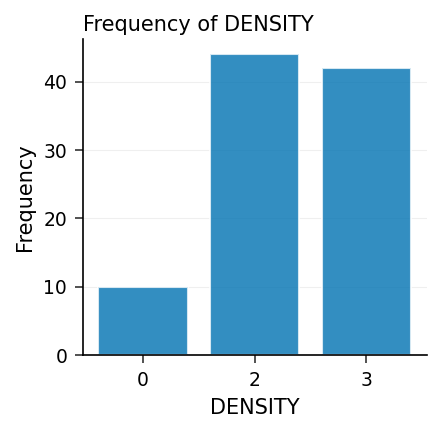

In [2]:
처리 GREDUCE 데이터=zonemap out=reducedmap;
    id zone;
실행;

처리 빈도 데이터=reducedmap;
    TABLES DENSITY / nocum;
    라벨 DENSITY = "밀도 등급(DENSITY)";
    제목 "밀도(DENSITY) 등급별 유지된 경계점 수";
실행;

## 3단계 — 밀도 등급 살펴보기

빈도표는 GREDUCE가 96개 경계점을 어떻게 분류했는지 보여줍니다:

| DENSITY | 점 개수 | 비율 |
|---------|--------|-------|
| 0 | 10 | 10.4% |
| 2 | 44 | 45.8% |
| 3 | 42 | 43.8% |

가장 낮은 등급을 가진 점은 10개뿐이며(핵심 형태를 지지하는 점), 나머지 86개는 등급 2와 3에 나뉘어 있습니다. 대시보드 등급으로는 `DENSITY <= 2`인 모든 점을 유지합니다: 이는 96개 중 54개를 남기고, 가장 세밀한 상세도(`DENSITY=3`)를 가진 42개 정점을 제거합니다. 아래 PROC MEANS는 저해상도 등급이 원래의 24개 대신 구역당 13~14개의 정점을 가짐을 확인해줍니다.

In [3]:
처리 평균 데이터=reducedmap n;
    분류 zone;
    조건 DENSITY <= 2;
    변수 x;
    라벨 zone = "배송권역";
    제목 "대시보드 상세도(DENSITY <= 2)에서 구역별 유지된 정점 수";
실행;

                                         대시보드 상세도(DENSITY <= 2)에서 구역별 유지된 정점 수                                          

                                                  The MEANS Procedure

                                                 Analysis Variable : X

        배송권역                  N Obs
        ---------------------------
        1                        14
        2                        13
        3                        14
        4                        13
        ---------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4단계 — 저해상도 지도와 구역별 성과 응답 구축

PROC GMAP이 축소된 윤곽을 바로 그릴 수 있도록 대시보드 등급을 `coarsemap`(`DENSITY <= 2`)으로 구체화합니다. 또한 GMAP이 각 영역을 색칠할 수 있도록 `zone`을 키로 하여 구역당 KPI 행 하나 — **정시배송율**과 **일일 소포 물량** — 을 합성합니다.

In [4]:
데이터 coarsemap;
    설정 reducedmap;
    조건 DENSITY <= 2;
실행;

데이터 zonekpi;
    호출 streaminit(771);
    반복 zone = 1 까지 4;
        /* on-time rate centered near 92%, realistic spread */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        출력;
    종료;
    라벨 zone        = "배송권역"
          ontime_rate  = "정시배송율(%)"
          parcels      = "일일 소포 물량";
실행;

처리 인쇄 데이터=zonekpi noobs 라벨;
    제목 "구역별 합성 배송 KPI";
실행;

                                                     구역별 합성 배송 KPI                                                      

        배송권역            정시배송율(%)              일일 소포 물량
           1                92.6                  4704
           2                95.6                  2932
           3                93.4                  2934
           4                94.6                  2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


네 개의 합성 정시배송율은 92.6%에서 95.6% 사이에 위치하며, 일일 소포 물량은 약 2,500~4,700 사이입니다. 구역 2가 95.6%로 가장 우수하고, 구역 1이 92.6%로 가장 저조합니다. 이 값들이 단계구분도의 색상 구간으로 표현됩니다.

## 5단계 — 전체 상세도와 축소 상세도 단계구분도 렌더링

동일한 정시배송 단계구분도를 두 번 그립니다: 한 번은 96개 정점을 가진 전체 `reducedmap`으로, 한 번은 54개 정점을 가진 `coarsemap`으로 그립니다. `MAP=`은 경계를, `DATA=`는 KPI 응답을 제공하며, 둘 다 `zone` ID를 공유합니다. `CHORO` 문은 `LEVELS=4` 색상 구간으로 각 구역을 `ontime_rate`에 따라 채우고, `COUTLINE=`로 선명한 경계선을 그립니다. 두 지도를 비교하면 축소가 시각적으로 어떤 대가를 치르는지 알 수 있습니다.

                                                   전체 상세도: 경계 정점 96개                                                    




NOTE: Option TITLE changed to 전체 상세도: 경계 정점 96개.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable 정시배송율(%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.39 seconds
  cpu   0.39 seconds


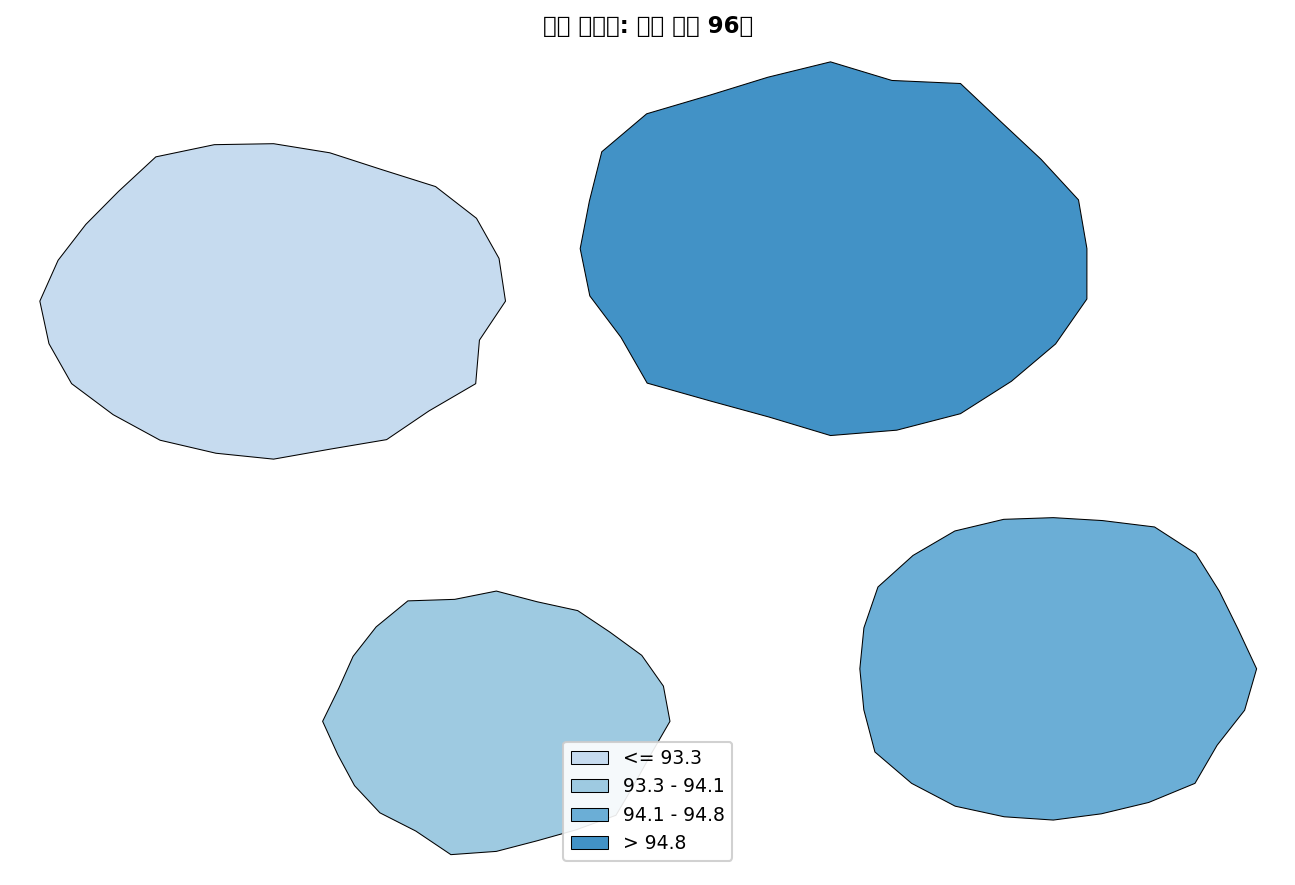

In [5]:
제목 "전체 상세도: 경계 정점 96개";
처리 GMAP map=reducedmap 데이터=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
실행;

                                             축소 상세도: 정점 54개 (DENSITY <= 2)                                              




NOTE: Option TITLE changed to 축소 상세도: 정점 54개 (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable 정시배송율(%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.39 seconds
  cpu   0.39 seconds


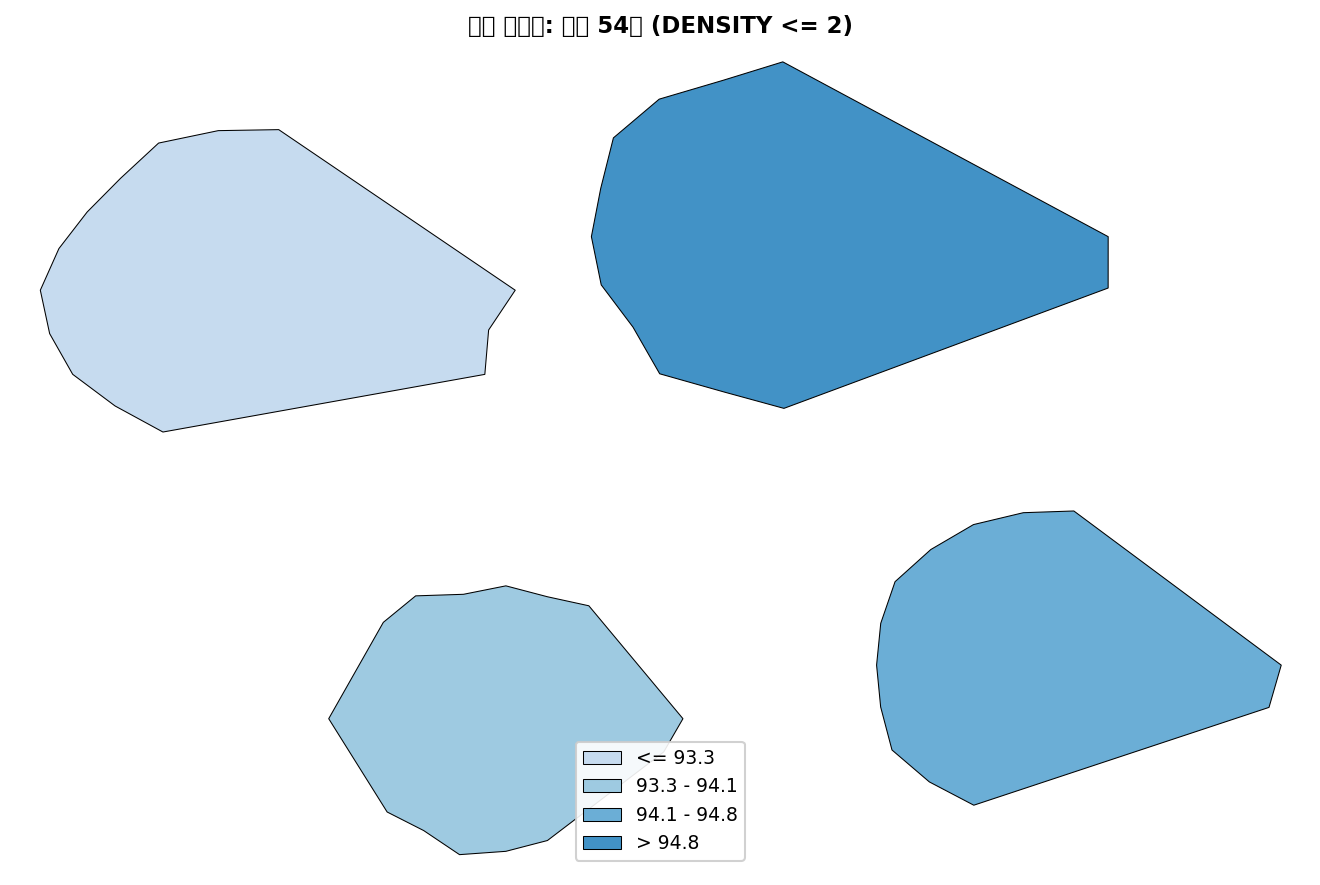

In [6]:
제목 "축소 상세도: 정점 54개 (DENSITY <= 2)";
처리 GMAP map=coarsemap 데이터=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
실행;

## 결과 해석

PROC GREDUCE는 24개 정점을 가진 각 구역 윤곽을 등급이 매겨진 경계점 집합(이번 실행에서는 등급 0, 2, 3)으로 바꾸었습니다. `DENSITY <= 2` 등급을 선택하면 지도는 96개 정점에서 54개로 줄어들어 — 렌더러가 그려야 할 점이 44% 감소 — 그럼에도 나란히 배치된 단계구분도는 네 구역이 여전히 뚜렷하게 구분됨을 확인해줍니다: 축소된 지도의 윤곽은 눈에 띄게 더 각져 있지만, 각 영역은 위치, 크기, 색상 구간을 그대로 유지하므로 운영자는 어느 쪽을 봐도 동일한 성과표를 읽을 수 있습니다.

그 성과표는 정시배송율로 구역 순위를 매깁니다: 구역 2가 95.6%로 선두(가장 짙은 구간)이고, 구역 3과 4는 93~95% 부근으로 중위권이며, 구역 1은 92.6%(가장 옅은 구간)로 뒤처집니다 — 경로 계획이나 창고 용량 문제를 가장 먼저 조사해야 할 영역입니다.

축소가 비파괴적이므로 — 전체 상세도의 점들은 여전히 `reducedmap`에 남아 있습니다 — 동일한 데이터셋이 `WHERE` 임계값 하나만 바꾸면 빠른 대시보드 뷰(`DENSITY <= 2`)와 고해상도 인쇄 또는 감사 뷰(`DENSITY <= 3` 또는 전체 집합) 둘 다를 지원하며, 지오메트리를 다시 가져오거나 다시 축소할 필요가 없습니다.